# Kaggle Predict F1 Pit Stops: EDA and Circuit Context

This notebook builds the evidence base for the modeling workflow. It checks whether the data is reliable, identifies the strongest raw and interaction signals, and records the train/test distribution context that later notebooks need for validation and feature design.

## 1. Setup and Configuration

This section imports the analysis stack, standardizes display and plotting defaults, and defines shared constants such as the target and ID columns. Keeping these values together makes the rest of the notebook easier to audit and keeps metric/plot behavior consistent.

In [1]:
import gc
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.frameon": False,
    }
)

RANDOM_STATE = 42
TARGET = "PitNextLap"
ID_COL = "id"


## 2. Load Data

Here we read the Kaggle competition files from the fixed competition path, load train/test/submission data, and reduce dataframe memory usage. The goal is to preserve the raw columns needed for EDA and later feature engineering while matching the Kaggle training environment.

In [2]:
def reduce_memory_usage(df: pd.DataFrame) -> pd.DataFrame:
    """Downcast dataframe columns to reduce notebook memory usage."""
    out = df.copy()
    for col in out.columns:
        dtype = out[col].dtype
        if pd.api.types.is_integer_dtype(dtype):
            out[col] = pd.to_numeric(out[col], downcast="integer")
        elif pd.api.types.is_float_dtype(dtype):
            out[col] = pd.to_numeric(out[col], downcast="float")
        elif pd.api.types.is_object_dtype(dtype):
            nunique = out[col].nunique(dropna=False)
            if nunique / max(len(out), 1) < 0.5:
                out[col] = out[col].astype("category")
    return out


DATA_DIR = Path("/kaggle/input/competitions/playground-series-s6e5")
OUTPUT_DIR = Path("/kaggle/working")

train = reduce_memory_usage(pd.read_csv(DATA_DIR / "train.csv"))
test = reduce_memory_usage(pd.read_csv(DATA_DIR / "test.csv"))
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"DATA_DIR: {DATA_DIR}")
print(f"train: {train.shape}")
print(f"test: {test.shape}")
print(f"target positive rate: {train[TARGET].mean():.5f}")
train.head()


DATA_DIR: /kaggle/input/competitions/playground-series-s6e5
train: (439140, 16)
test: (188165, 15)
target positive rate: 0.19898


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.490997,-7.564000,21.018999,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095001,-32.617001,-223.207001,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945000,-7.540000,-100.528999,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361000,-7.324000,-7.324000,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.877998,8.965000,-14.139000,0.361111,3.0,0.0


## 3. Data Quality

Before interpreting any signal, we check schema shape, data types, missing values, duplicated rows, duplicated IDs, and train/test ID overlap. These checks tell us whether modeling effort should start with cleaning or can move directly into feature and validation design.

In [3]:
def dataframe_overview(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Summarize column types, missingness, and unique values."""
    return pd.DataFrame({
        "dataset": name,
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean().mul(100),
        "unique": df.nunique(dropna=False),
        "memory_mb": df.memory_usage(deep=True).div(1024 ** 2),
    }).sort_values(["missing_pct", "unique"], ascending=[False, False])

quality_checks = pd.DataFrame({
    "check": [
        "train duplicated rows",
        "test duplicated rows",
        "train duplicated id",
        "test duplicated id",
        "train/test id overlap",
    ],
    "value": [
        int(train.duplicated().sum()),
        int(test.duplicated().sum()),
        int(train[ID_COL].duplicated().sum()),
        int(test[ID_COL].duplicated().sum()),
        int(pd.Index(train[ID_COL]).intersection(test[ID_COL]).shape[0]),
    ],
})

display(pd.concat([
    dataframe_overview(train, "train"),
    dataframe_overview(test, "test"),
]))
display(quality_checks)
train.describe(include="all").T


,dataset,dtype,missing,missing_pct,unique,memory_mb
id,train,int32,0.0,0.0,439140.0,1.675186
Cumulative_Degradation,train,float32,0.0,0.0,87482.0,1.675186
LapTime_Delta,train,float32,0.0,0.0,44485.0,1.675186
LapTime (s),train,float32,0.0,0.0,37700.0,1.675186
RaceProgress,train,float32,0.0,0.0,1618.0,1.675186
Driver,train,category,0.0,0.0,887.0,0.913834
LapNumber,train,int8,0.0,0.0,78.0,0.418797
TyreLife,train,float32,0.0,0.0,78.0,1.675186
Position_Change,train,float32,0.0,0.0,37.0,1.675186
Race,train,category,0.0,0.0,26.0,0.421549


,check,value
0,train duplicated rows,0
1,test duplicated rows,0
2,train duplicated id,0
3,test duplicated id,0
4,train/test id overlap,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,439140.0,NaN,NaN,NaN,219569.5,126768.942943,0.0,109784.75,219569.5,329354.25,439139.0
Driver,439140,887,MAS,1682,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Compound,439140,5,MEDIUM,211141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Race,439140,26,Dutch Grand Prix,24462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,439140.0,NaN,NaN,NaN,2023.523544,1.02493,2022.0,2023.0,2024.0,2024.0,2025.0
PitStop,439140.0,NaN,NaN,NaN,0.136118,0.342915,0.0,0.0,0.0,0.0,1.0
LapNumber,439140.0,NaN,NaN,NaN,23.105909,16.958261,1.0,9.0,19.0,36.0,78.0
Stint,439140.0,NaN,NaN,NaN,1.789113,0.950194,1.0,1.0,2.0,2.0,8.0
TyreLife,439140.0,NaN,NaN,NaN,14.158231,9.801338,1.0,6.0,12.0,20.0,77.0
Position,439140.0,NaN,NaN,NaN,9.630339,5.27877,1.0,5.0,10.0,14.0,20.0


## 4. Target and Categorical Signal

This section measures the class balance and compares pit-next-lap rates across categorical fields. The target rate sets expectations for average precision, while category-level differences reveal whether strategy identifiers such as compound, race, team, or driver carry meaningful signal.

,count,pct
PitNextLap,,
0.0,351759,0.801018
1.0,87381,0.198982


Positive rate: 0.19898


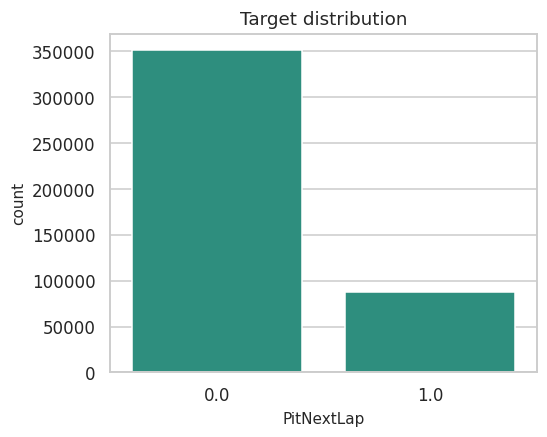

,feature,value,count,target_rate,global_rate_diff
889,Compound,MEDIUM,211141,0.101131,-0.097851
887,Compound,HARD,170518,0.327537,0.128555
890,Compound,SOFT,38744,0.193475,-0.005507
888,Compound,INTERMEDIATE,17382,0.152284,-0.046698
891,Compound,WET,1355,0.025092,-0.173890
830,Driver,MAS,1682,0.231272,0.032290
849,Driver,RAI,1669,0.242660,0.043678
8,Driver,BAR,1656,0.219807,0.020825
19,Driver,BUT,1655,0.245317,0.046335
792,Driver,FIS,1651,0.219867,0.020885


In [4]:
target_counts = train[TARGET].value_counts().sort_index()
display(pd.DataFrame({"count": target_counts, "pct": target_counts / len(train)}))
print(f"Positive rate: {train[TARGET].mean():.5f}")

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=train, x=TARGET, color=sns.color_palette("viridis", 8)[4], ax=ax)
ax.set_title("Target distribution")
plt.show()

categorical_cols = (
    train.drop(columns=[TARGET])
    .select_dtypes(include=["object", "category"])
    .columns.tolist()
)
cat_rows = []
for col in categorical_cols:
    stats = train.groupby(col, observed=True)[TARGET].agg(["count", "mean"]).reset_index()
    stats["feature"] = col
    stats = stats.rename(columns={col: "value", "mean": "target_rate"})
    stats["global_rate_diff"] = stats["target_rate"] - train[TARGET].mean()
    cat_rows.append(stats[["feature", "value", "count", "target_rate", "global_rate_diff"]])
cat_summary = pd.concat(cat_rows, ignore_index=True)
cat_summary.sort_values(["feature", "count"], ascending=[True, False]).head(50)


## 5. Numerical Signal and Outliers

Numerical summaries show the scale, spread, and extreme values of lap, tyre, position, and timing features. We inspect these fields because pit-stop decisions are driven by nonlinear thresholds, and unusually large timing or degradation values can be informative rather than simple noise.

,count,mean,std,min,median,max
Year,439140.0,2023.523544,1.024930,2022.000000,2024.000000,2025.000000
PitStop,439140.0,0.136118,0.342915,0.000000,0.000000,1.000000
LapNumber,439140.0,23.105909,16.958261,1.000000,19.000000,78.000000
Stint,439140.0,1.789113,0.950194,1.000000,2.000000,8.000000
TyreLife,439140.0,14.158231,9.801338,1.000000,12.000000,77.000000
Position,439140.0,9.630339,5.278770,1.000000,10.000000,20.000000
LapTime (s),439140.0,90.948753,19.770432,67.694000,90.521004,2507.606934
LapTime_Delta,439140.0,-3.770040,43.910587,-2403.895020,-0.295000,2423.931885
Cumulative_Degradation,439140.0,-25.721764,54.755814,-274.563995,-20.993999,2412.025879
RaceProgress,439140.0,0.337661,0.253286,0.012821,0.269231,1.000000


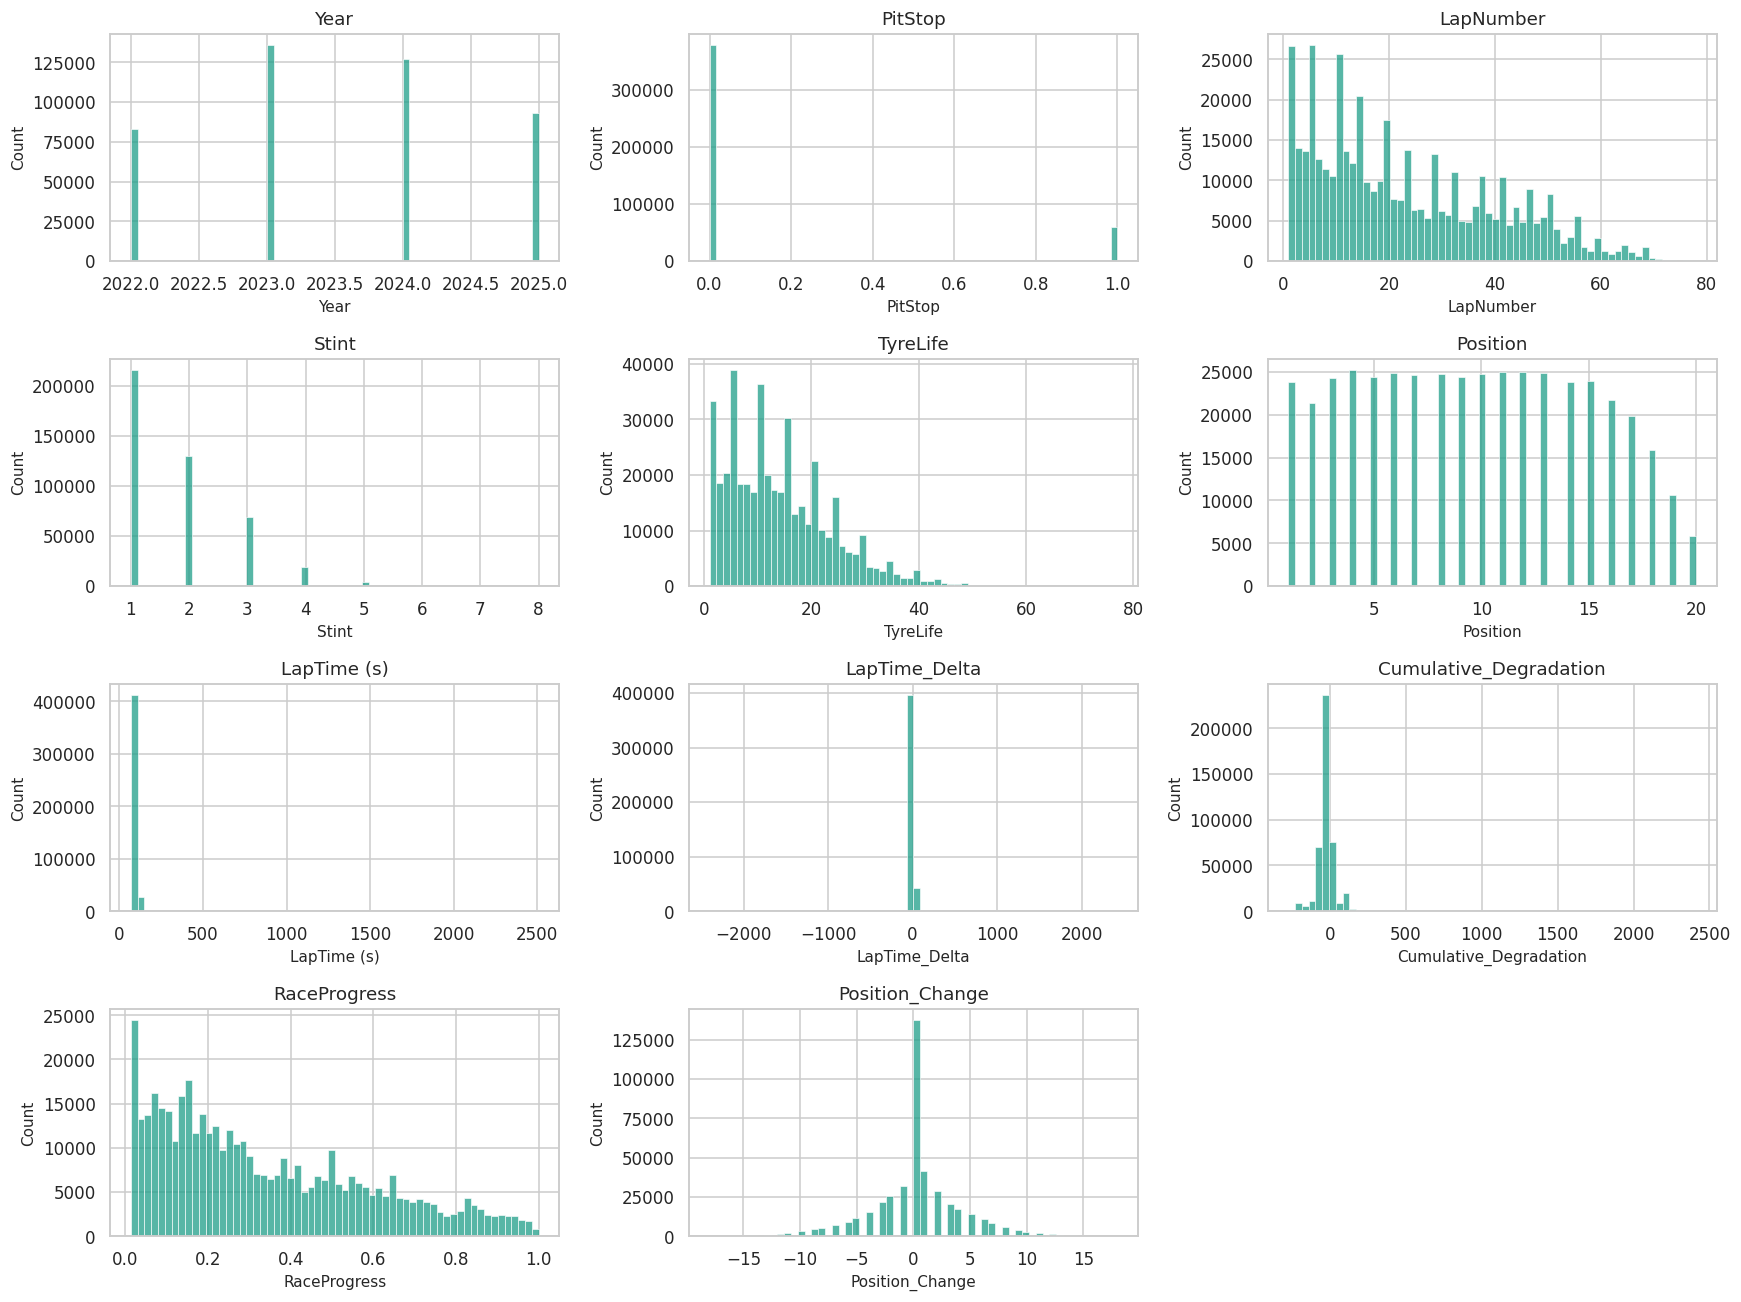

,feature,min,q0.001,median,q0.999,max,below_low,above_high
7,LapTime_Delta,-2403.895020,-63.238998,-0.295000,49.362582,2423.931885,438,440
10,Position_Change,-18.000000,-15.000000,0.000000,14.000000,18.000000,404,438
6,LapTime (s),67.694000,69.631276,90.521004,146.673996,2507.606934,440,437
4,TyreLife,1.000000,1.000000,12.000000,61.000000,77.000000,0,428
9,RaceProgress,0.012821,0.012821,0.269231,0.986111,1.000000,0,418
8,Cumulative_Degradation,-274.563995,-262.619931,-20.993999,147.345993,2412.025879,440,395
2,LapNumber,1.000000,1.000000,19.000000,71.000000,78.000000,0,332
3,Stint,1.000000,1.000000,2.000000,6.000000,8.000000,0,166
0,Year,2022.000000,2022.000000,2024.000000,2025.000000,2025.000000,0,0
1,PitStop,0.000000,0.000000,0.000000,1.000000,1.000000,0,0


In [5]:
numeric_cols = [c for c in train.columns if c not in categorical_cols + [TARGET, ID_COL]]
display(train[numeric_cols + [TARGET]].agg(["count", "mean", "std", "min", "median", "max"]).T)

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, max(4, 3 * n_rows)))
axes = np.ravel(axes)
for ax, col in zip(axes, numeric_cols):
    sns.histplot(train[col], bins=60, color=sns.color_palette("viridis", 8)[4], ax=ax)
    ax.set_title(col)
for ax in axes[len(numeric_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

outlier_rows = []
for col in numeric_cols:
    low, high = train[col].quantile([0.001, 0.999])
    outlier_rows.append({
        "feature": col,
        "min": train[col].min(),
        "q0.001": low,
        "median": train[col].median(),
        "q0.999": high,
        "max": train[col].max(),
        "below_low": int((train[col] < low).sum()),
        "above_high": int((train[col] > high).sum()),
    })
pd.DataFrame(outlier_rows).sort_values("above_high", ascending=False)


## 6. Strategy Interactions

Pit strategy is rarely explained by one column in isolation. This section studies compound-by-stint behavior and tyre-life-by-race-progress patterns to reveal interactions that should be represented in feature engineering and handled by nonlinear models.

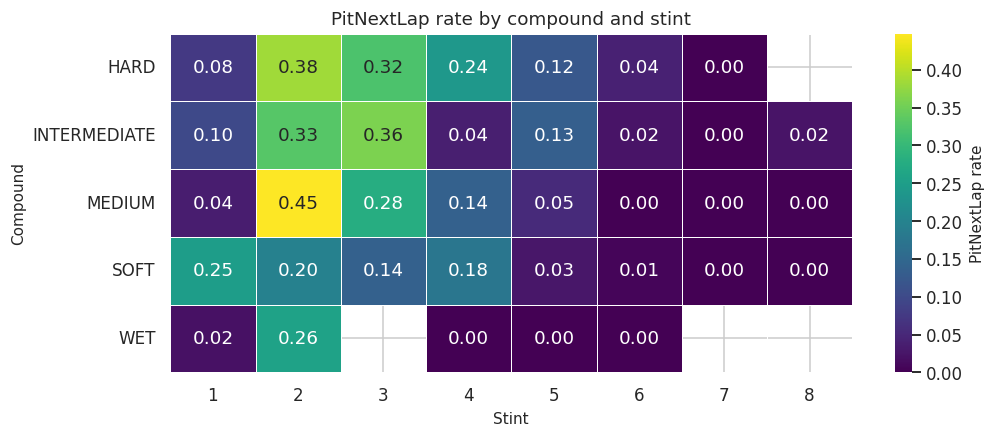

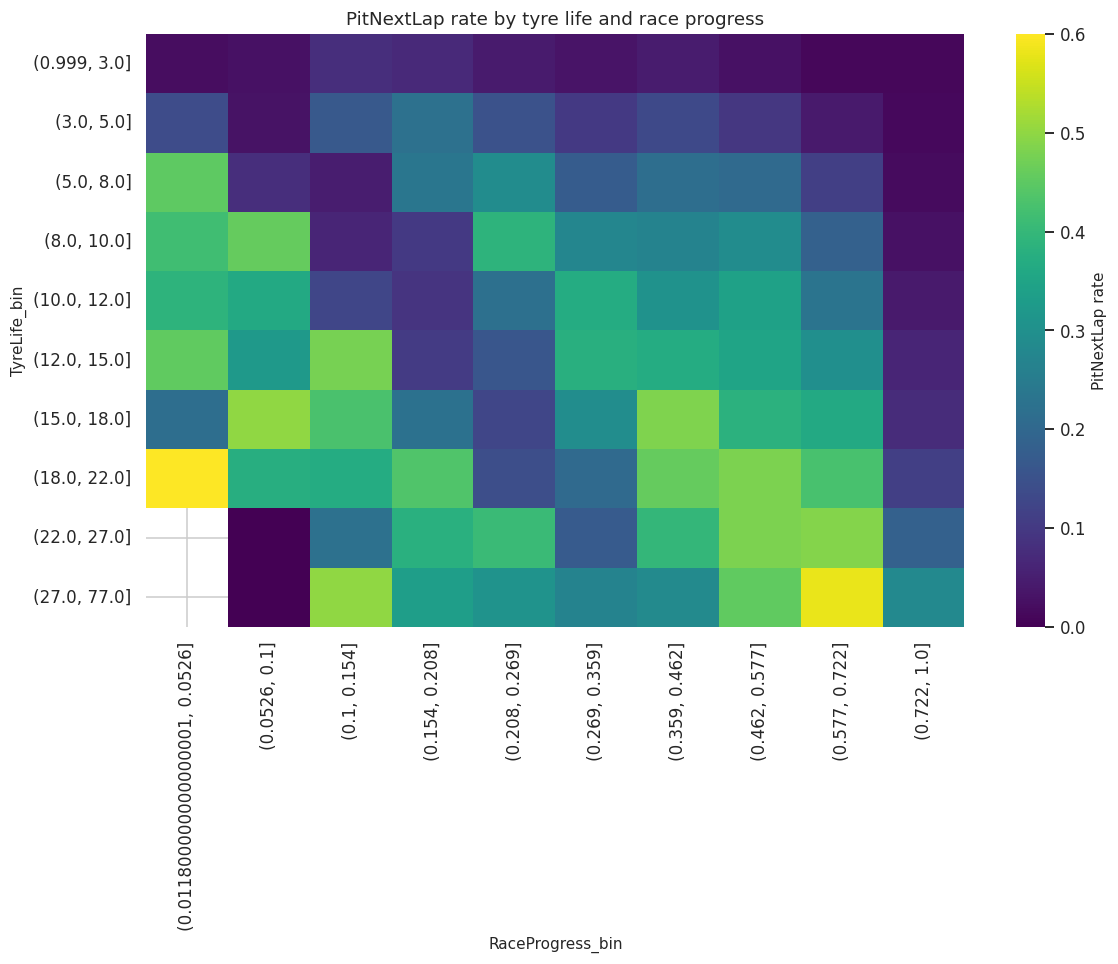

In [6]:
compound_stint = (
    train.groupby(["Compound", "Stint"], observed=True)[TARGET]
    .agg(["count", "mean"])
    .reset_index()
)
compound_stint_pivot = compound_stint.pivot(
    index="Compound",
    columns="Stint",
    values="mean",
)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    compound_stint_pivot,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "PitNextLap rate"},
    ax=ax,
)
ax.set_title("PitNextLap rate by compound and stint")
plt.show()

interaction_df = train[["TyreLife", "RaceProgress", TARGET]].copy()
interaction_df["TyreLife_bin"] = pd.qcut(
    interaction_df["TyreLife"],
    q=10,
    duplicates="drop",
)
interaction_df["RaceProgress_bin"] = pd.qcut(
    interaction_df["RaceProgress"],
    q=10,
    duplicates="drop",
)
interaction_rate = interaction_df.pivot_table(
    index="TyreLife_bin",
    columns="RaceProgress_bin",
    values=TARGET,
    aggfunc="mean",
    observed=True,
)
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    interaction_rate,
    cmap="viridis",
    cbar_kws={"label": "PitNextLap rate"},
    ax=ax,
)
ax.set_title("PitNextLap rate by tyre life and race progress")
plt.show()


## 7. Train/Test Drift

This section compares train and test distributions using category coverage and numeric PSI. The purpose is to understand whether validation can rely on ordinary stratified folds or whether the test set appears shifted enough to require a more specialized split strategy.

In [7]:
def psi(
    train_s: pd.Series,
    test_s: pd.Series,
    bins: int = 20,
    eps: float = 1e-6,
) -> float:
    """Calculate population stability index between train and test."""
    edges = np.unique(train_s.quantile(np.linspace(0, 1, bins + 1)).to_numpy())
    if len(edges) <= 2:
        edges = np.linspace(
            min(train_s.min(), test_s.min()),
            max(train_s.max(), test_s.max()),
            bins + 1,
        )
    edges[0], edges[-1] = -np.inf, np.inf
    train_pct = (
        pd.cut(train_s, edges, include_lowest=True)
        .value_counts(normalize=True, sort=False)
        .to_numpy()
    )
    test_pct = (
        pd.cut(test_s, edges, include_lowest=True)
        .value_counts(normalize=True, sort=False)
        .to_numpy()
    )
    train_pct = np.clip(train_pct, eps, None)
    test_pct = np.clip(test_pct, eps, None)
    return float(np.sum((test_pct - train_pct) * np.log(test_pct / train_pct)))

category_coverage = []
for col in categorical_cols:
    train_values = set(train[col].dropna().astype(str))
    test_values = set(test[col].dropna().astype(str))
    category_coverage.append({
        "feature": col,
        "train_unique": len(train_values),
        "test_unique": len(test_values),
        "test_only": len(test_values - train_values),
        "train_only": len(train_values - test_values),
    })
display(pd.DataFrame(category_coverage))

drift = pd.DataFrame([{
    "feature": col,
    "train_mean": train[col].mean(),
    "test_mean": test[col].mean(),
    "mean_diff": test[col].mean() - train[col].mean(),
    "psi": psi(train[col], test[col]),
} for col in numeric_cols]).sort_values("psi", ascending=False)
drift


,feature,train_unique,test_unique,test_only,train_only
0,Driver,887,801,0,86
1,Compound,5,5,0,0
2,Race,26,26,0,0


,feature,train_mean,test_mean,mean_diff,psi
4,TyreLife,14.158231,14.160625,0.002395,1.856812e-04
9,RaceProgress,0.337661,0.336695,-0.000966,1.771904e-04
2,LapNumber,23.105909,23.050185,-0.055725,1.644566e-04
6,LapTime (s),90.948753,90.986870,0.038116,1.052125e-04
8,Cumulative_Degradation,-25.721764,-25.849489,-0.127726,9.570485e-05
7,LapTime_Delta,-3.770040,-3.577803,0.192237,6.991453e-05
5,Position,9.630339,9.604539,-0.025800,5.601398e-05
10,Position_Change,0.101542,0.106800,0.005258,4.228599e-05
0,Year,2023.523544,2023.528440,0.004897,2.273061e-05
3,Stint,1.789113,1.784237,-0.004876,2.037482e-05


## 8. Circuit Context

Race-level summaries capture how pit behavior changes by season and Grand Prix. This matters because the same tyre-life value can imply different risk depending on circuit, race length, and strategy pattern.

,Year,Race,rows,pit_next_lap_rate,mean_lap,median_tyre_life,mean_race_progress
70,2024,Monaco Grand Prix,6002,0.760247,31.241253,25.0,0.407214
83,2025,Belgian Grand Prix,1552,0.553479,20.563144,11.0,0.271379
6,2022,British Grand Prix,2532,0.501580,21.197077,11.0,0.295934
75,2024,Spanish Grand Prix,6040,0.501159,26.284437,12.0,0.348168
66,2024,Japanese Grand Prix,2800,0.492857,25.897500,12.0,0.346102
82,2025,Bahrain Grand Prix,3396,0.476737,23.408716,10.0,0.312617
55,2024,Azerbaijan Grand Prix,2597,0.457066,19.787062,13.0,0.263602
67,2024,Las Vegas Grand Prix,4609,0.439575,19.286396,10.0,0.257414
101,2025,Spanish Grand Prix,3947,0.417532,26.245756,11.0,0.346361
4,2022,Bahrain Grand Prix,4034,0.416708,21.068171,9.0,0.295958


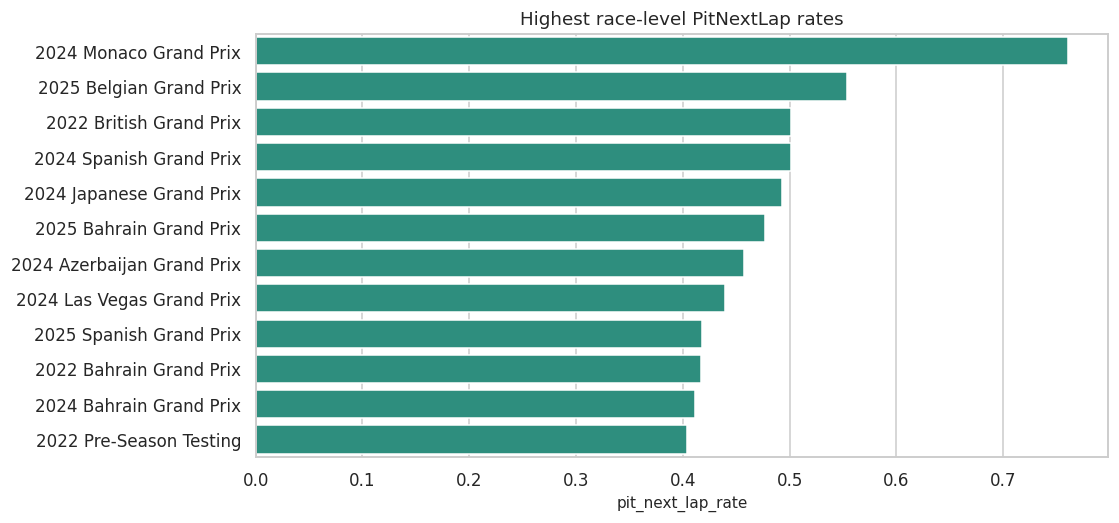

FastF1 unavailable; circuit-map drawing skipped.
No module named 'fastf1'


In [8]:
race_summary = (
    train.groupby(["Year", "Race"], observed=True)
    .agg(
        rows=(TARGET, "size"),
        pit_next_lap_rate=(TARGET, "mean"),
        mean_lap=("LapNumber", "mean"),
        median_tyre_life=("TyreLife", "median"),
        mean_race_progress=("RaceProgress", "mean"),
    )
    .reset_index()
    .sort_values("pit_next_lap_rate", ascending=False)
)
display(race_summary.head(20))

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = race_summary.head(12).copy()
plot_df["label"] = plot_df["Year"].astype(str) + " " + plot_df["Race"].astype(str)
sns.barplot(
    data=plot_df,
    y="label",
    x="pit_next_lap_rate",
    color=sns.color_palette("viridis", 8)[4],
    ax=ax,
)
ax.set_title("Highest race-level PitNextLap rates")
ax.set_ylabel("")
plt.show()

try:
    import fastf1
    print("FastF1 available for optional circuit-map context.")
except Exception as exc:
    print("FastF1 unavailable; circuit-map drawing skipped.")
    print(exc)


## 9. EDA Summary

The EDA supports a clean modeling path: the dataset is stable, the target rate is about 20%, compound/stint and tyre-life/race-progress interactions are central, lap-time and degradation extremes are useful, and train/test drift is low. The next notebooks should prioritize tree models, compact row-safe ratio features, and race-level calibration diagnostics.